# Проект "Предсказание вероятности ДТП"

**Описание проекта:**  
Каршеринговая компания обратилась с просьбой провести исследование на предмет возможности предсказания ДТП по выбранному маршруту.  
**Цель проекта:**  
Провести исследование и разработать модель, которая будет предсказывать ДТП, либо опровергнуть теорию о том, что по маршруту можно делать подобные предсказания.  
*Описание данных:*   
collisions (информация о происшествиях)   
Parties (описание участников происшествия)   
Vehicles (Описание автомобиля)   

*Этапы проекта:*  
1. Загрузить данные:  
   1. Импортируем библиотеки.  
   2. Загрузим данные.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Создание модели
   1. Создадим несколько моделей.
   2. Обучим их.
   3. Выберем лучшие.
   4. Проверим на реальных данных.
5. Вывод.


## Загрузка данных

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import warnings


RANDOM_STATE = 42

In [2]:
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="sklearn"
)

In [3]:
db_config = {
    'user': 'praktikum_student',
    'pwd': 'Sdf4$2;d-d30pp',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'db': 'data-science-vehicle-db'
}

engine = create_engine(
    f"postgresql://{db_config['user']}:{db_config['pwd']}"
    f"@{db_config['host']}:{db_config['port']}/{db_config['db']}"
)


In [4]:
pd.read_sql("SELECT COUNT(*) FROM collisions", engine)

,count
0,1400000


In [5]:
pd.read_sql("SELECT COUNT(*) FROM parties", engine)

,count
0,2752408


In [6]:
pd.read_sql("SELECT COUNT(*) FROM vehicles", engine)

,count
0,1021234


Все таблицы имеют записи.

Проверим данные в таблицах, проверим как записи распределены по годам.

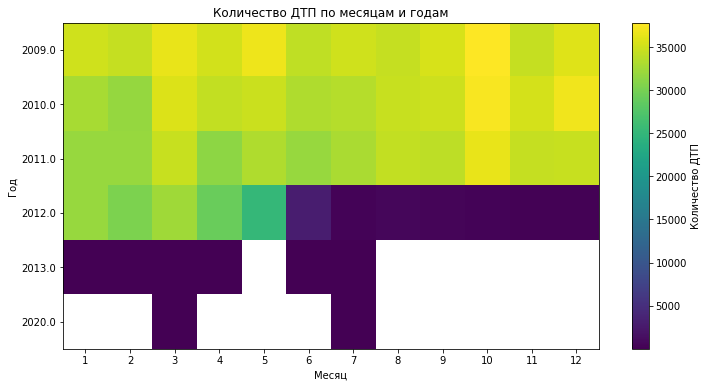

In [7]:
query = """
SELECT
    EXTRACT(YEAR FROM collision_date)  AS year,
    EXTRACT(MONTH FROM collision_date) AS month,
    COUNT(*) AS accidents
FROM collisions
GROUP BY year, month
ORDER BY year, month
"""
df = pd.read_sql(query, engine)

pivot = df.pivot(index='year', columns='month', values='accidents')

plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect='auto')
plt.colorbar(label='Количество ДТП')
plt.xticks(range(12), range(1,13))
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('Месяц')
plt.ylabel('Год')
plt.title('Количество ДТП по месяцам и годам')
plt.show()

In [8]:
months_per_year = (
    df.groupby('year')
      .agg(
          months_count=('month', 'nunique'),
          min_accidents=('accidents', 'min')
      )
)

valid_years = months_per_year[
    (months_per_year['months_count'] == 12) &
    (months_per_year['min_accidents'] > 0)
].index

In [9]:
df = df[df['year'].isin(valid_years)]

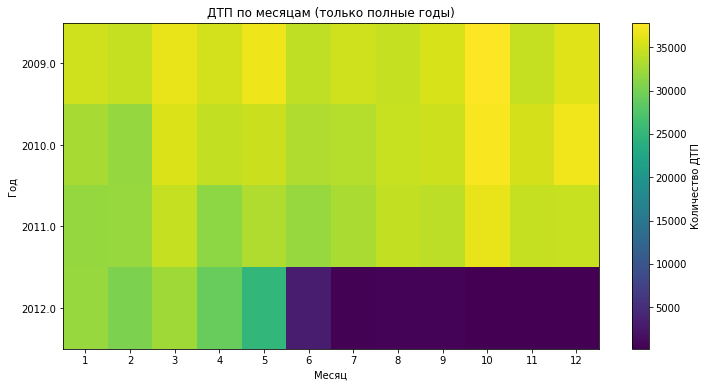

In [10]:
pivot = df.pivot(index='year', columns='month', values='accidents')

plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect='auto')
plt.colorbar(label='Количество ДТП')
plt.xticks(range(12), range(1,13))
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('Месяц')
plt.ylabel('Год')
plt.title('ДТП по месяцам (только полные годы)')
plt.show()

Наибольшее количество ДТП приходится на весенне-зимний период,
что может быть связано с ухудшением погодных и дорожных условий.

## Аналитические задачи для коллег

1. Проанализировать зависимость серьёзности повреждений от состояния дороги.
2. Исследовать влияние погодных условий на вероятность быть виновником ДТП.
3. Изучить влияние возраста автомобиля на виновность.
4. Проанализировать типы столкновений и их тяжесть.
5. Оценить влияние освещённости на риск ДТП.
6. Исследовать использование телефона и виновность в ДТП.

## Зависимость серьёзных повреждений от состояния дороги

In [11]:
query = """
WITH surface_stats AS (
    SELECT
        ROAD_SURFACE,
        COLLISION_DAMAGE,
        COUNT(*) AS cnt
    FROM collisions
    WHERE ROAD_SURFACE != '-'
      AND COLLISION_DAMAGE IS NOT NULL
    GROUP BY ROAD_SURFACE, COLLISION_DAMAGE
),
totals AS (
    SELECT
        ROAD_SURFACE,
        SUM(cnt) AS total
    FROM surface_stats
    GROUP BY ROAD_SURFACE
)
SELECT
    s.ROAD_SURFACE,
    s.COLLISION_DAMAGE,
    s.cnt * 1.0 / t.total AS share
FROM surface_stats s
JOIN totals t USING (ROAD_SURFACE)
ORDER BY s.ROAD_SURFACE, s.COLLISION_DAMAGE
"""
df_surface = pd.read_sql(query, engine)


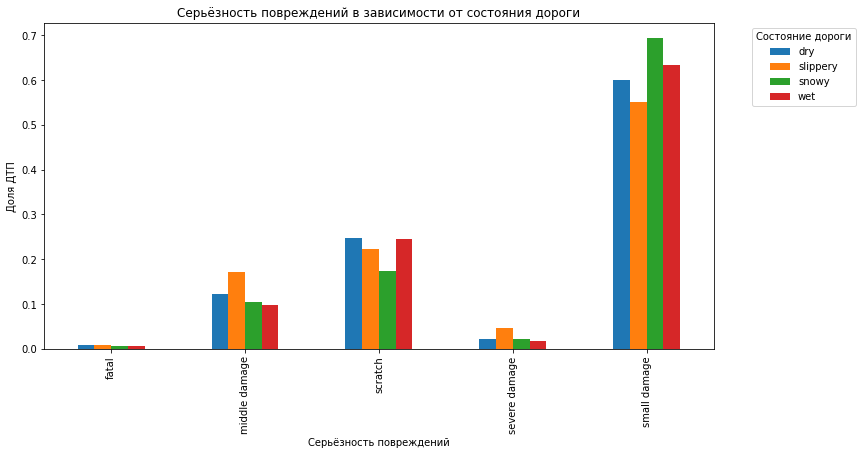

In [12]:
pivot_surface = df_surface.pivot(
    index='collision_damage',
    columns='road_surface',
    values='share'
)

pivot_surface.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Серьёзность повреждений')
plt.ylabel('Доля ДТП')
plt.title('Серьёзность повреждений в зависимости от состояния дороги')
plt.legend(title='Состояние дороги', bbox_to_anchor=(1.05, 1))
plt.show()

Вывод:  
Наиболее часто аварии типа fatal и middle damage случаются, когда покрытие дороги сухое или скользкое, варианты заснеженной и влажной дороги для данных типов аварий менее опасны.

## Влияние погодных условий на вероятность быть виновником ДТП.

In [13]:
query = """
WITH weather_fault AS (
    SELECT
        c.WEATHER_1,
        p.AT_FAULT,
        COUNT(*) AS cnt
    FROM collisions c
    JOIN parties p USING (CASE_ID)
    WHERE c.WEATHER_1 != '-'
      AND p.AT_FAULT IS NOT NULL
    GROUP BY c.WEATHER_1, p.AT_FAULT
),
totals AS (
    SELECT
        WEATHER_1,
        SUM(cnt) AS total
    FROM weather_fault
    GROUP BY WEATHER_1
)
SELECT
    w.WEATHER_1,
    w.AT_FAULT,
    w.cnt * 1.0 / t.total AS probability
FROM weather_fault w
JOIN totals t USING (WEATHER_1)
ORDER BY w.WEATHER_1, w.AT_FAULT
"""
df_weather = pd.read_sql(query, engine)


In [14]:
df_fault_prob = df_weather[df_weather['at_fault'] == 1]
df_fault_prob

,weather_1,at_fault,probability
1,clear,1,0.462307
3,cloudy,1,0.491210
5,fog,1,0.529827
7,other,1,0.431973
9,raining,1,0.510651
11,snowing,1,0.552868
13,wind,1,0.424280


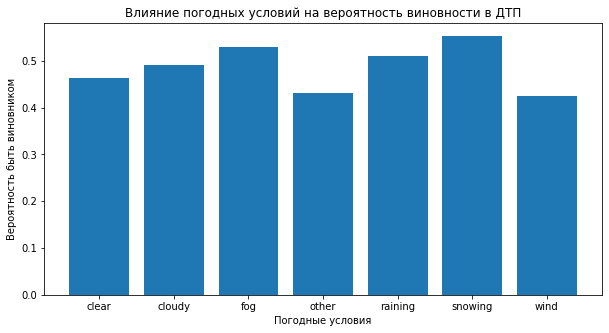

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(df_fault_prob['weather_1'], df_fault_prob['probability'])
plt.xlabel('Погодные условия')
plt.ylabel('Вероятность быть виновником')
plt.title('Влияние погодных условий на вероятность виновности в ДТП')
plt.show()

Анализ показал, что погодные условия оказывают заметное влияние на вероятность признания участника виновным в ДТП. При неблагоприятной погоде — особенно снегопаде, дожде и тумане — вероятность виновности выше, чем при ясной погоде. Наиболее низкие значения наблюдаются при ясной и ветреной погоде.

## Подготовка данных для модели

In [16]:
query = """
SELECT
    p.at_fault,
    v.vehicle_age,
    c.weather_1,
    c.road_surface,
    c.lighting,
    c.intersection,
    c.direction,
    c.location_type,
    c.road_condition_1,
    p.cellphone_in_use,
    v.vehicle_type,
    v.vehicle_transmission
FROM collisions c
JOIN parties p USING(case_id)
JOIN vehicles v
  ON p.case_id = v.case_id AND p.party_number = v.party_number
WHERE
    p.party_type = 'car'
    AND c.collision_damage != 'scratch'
    AND EXTRACT(YEAR FROM c.collision_date) = 2012
"""
df = pd.read_sql(query, engine)
df.head()

,at_fault,vehicle_age,weather_1,road_surface,lighting,intersection,direction,location_type,road_condition_1,cellphone_in_use,vehicle_type,vehicle_transmission
0,1,3.0,clear,dry,dark with street lights,0.0,south,highway,normal,0.0,sedan,manual
1,0,10.0,None,None,None,1.0,None,None,None,0.0,sedan,auto
2,0,5.0,cloudy,dry,dusk or dawn,0.0,west,highway,normal,0.0,sedan,auto
3,0,12.0,clear,dry,daylight,0.0,east,ramp,normal,0.0,sedan,auto
4,1,4.0,clear,dry,daylight,0.0,north,highway,normal,0.0,sedan,auto


Для построения модели были выбраны признаки, которые логически могут влиять на вероятность признания участника виновным в ДТП: условия окружающей среды, состояние дороги, особенности места аварии и характеристики автомобиля. Этих признаков достаточно для построения базовой модели, которая предсказывает дтп по маршруту. Из анализа исключены происшествия с минимальным ущербом (царапины), по условию задачи.

In [17]:
df.shape

(56248, 12)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56248 entries, 0 to 56247
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   at_fault              56248 non-null  int64  
 1   vehicle_age           54554 non-null  float64
 2   weather_1             56080 non-null  object 
 3   road_surface          55900 non-null  object 
 4   lighting              56094 non-null  object 
 5   intersection          56073 non-null  float64
 6   direction             43230 non-null  object 
 7   location_type         25932 non-null  object 
 8   road_condition_1      55999 non-null  object 
 9   cellphone_in_use      51777 non-null  float64
 10  vehicle_type          56248 non-null  object 
 11  vehicle_transmission  55389 non-null  object 
dtypes: float64(3), int64(1), object(8)
memory usage: 5.1+ MB


После объединения таблиц и фильтрации данных был получен датасет
из 103 267 наблюдений и 7 признаков.

Типы данных:
- целевая переменная `at_fault` — бинарный признак, `intersection`, `cellphone_in_use` - также бинарный;
- числовые признаки: `vehicle_age`, ;
- категориальные признаки: `weather_1`, `road_surface`,
  `lighting`, `direction`,`location_type`, `road_condition_1`, `vehicle_type`, `vehicle_transmission`.

В данных присутствуют пропущенные значения,
что требует предварительной обработки перед моделированием.

### Проведем исследовательский анализ данных

In [19]:
def plot_boxplot(df, column, title = None, figsize=(6,4)):
    plt.figure(figsize=figsize)
    df.boxplot(column=column)
    plt.title(title)
    plt.ylabel(column)
    plt.grid(True)
    plt.show()

In [20]:
def plot_distr(df, column, bins = 30, kde = True, figsize = (8,5), title = None):
    plt.figure(figsize=figsize)
    sns.histplot(df[column], bins=bins, kde = kde, color='skyblue', edgecolor='black')
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel('Частота')
    plt.grid(True)
    plt.show()

In [21]:
def plot_value_counts(df, column, figsize=(8,5), title = None):
    value_counts=df[column].value_counts()
    plt.figure(figsize=figsize)
    value_counts.plot(kind='bar', color='cornflowerblue', edgecolor='black')
    plt.title(title or f'Частота значений {column}')
    plt.xlabel(column)
    plt.ylabel('Количество')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y')
    plt.show()

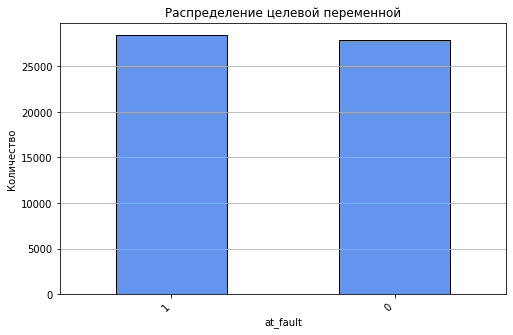

In [22]:
plot_value_counts(df, 'at_fault', title= 'Распределение целевой переменной')

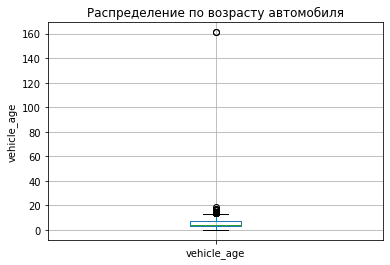

In [23]:
plot_boxplot(df, 'vehicle_age', title = 'Распределение по возрасту автомобиля')

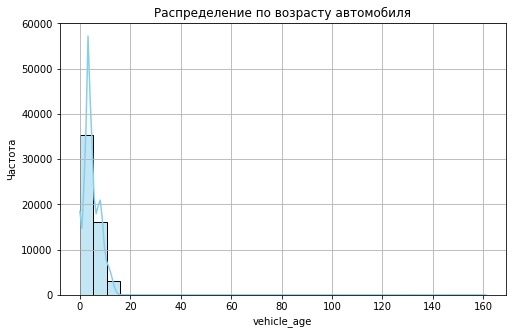

In [24]:
plot_distr(df, 'vehicle_age', title = 'Распределение по возрасту автомобиля')

In [25]:
print(df[df['vehicle_age'] >20])

       at_fault  vehicle_age weather_1 road_surface      lighting  \
26479         0        161.0     clear          dry  dusk or dawn   
28209         1        161.0     clear          dry      daylight   

       intersection direction location_type road_condition_1  \
26479           1.0      None          ramp           normal   
28209           0.0     north          None           normal   

       cellphone_in_use vehicle_type vehicle_transmission  
26479               0.0        sedan               manual  
28209               0.0        sedan               manual  


Удалим эти данные из датасета

In [26]:
df = df[~(df['vehicle_age'] > 20)]

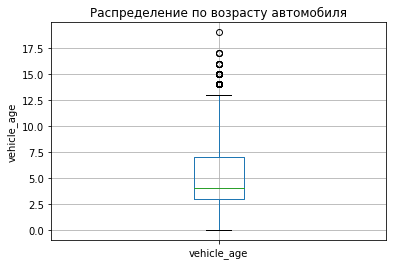

In [27]:
plot_boxplot(df, 'vehicle_age', title = 'Распределение по возрасту автомобиля')

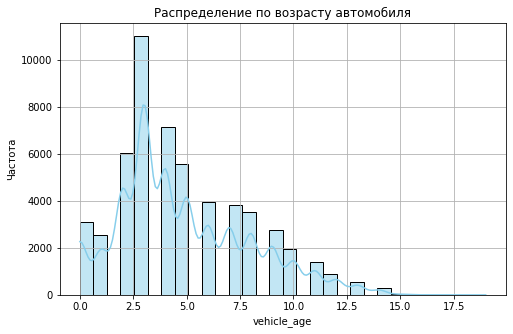

In [28]:
plot_distr(df, 'vehicle_age', title = 'Распределение по возрасту автомобиля')

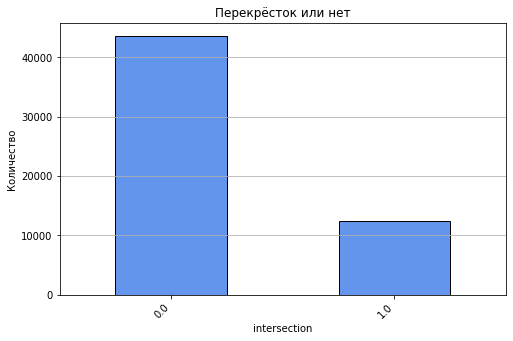

In [29]:
plot_value_counts(df, 'intersection', title = 'Перекрёсток или нет')

Большая часть аварий происходит не на перекрётсках.

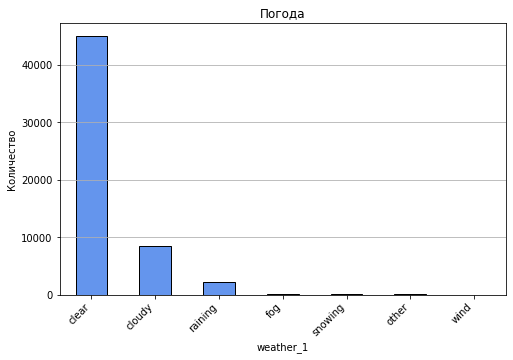

In [30]:
plot_value_counts(df, 'weather_1', title = 'Погода')

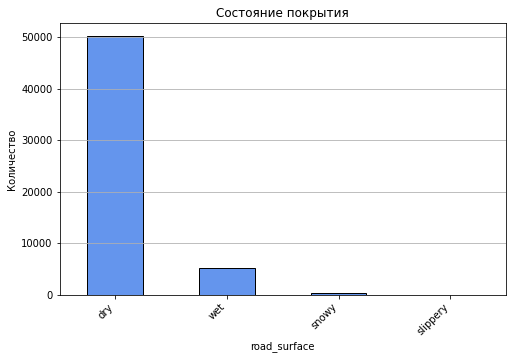

In [31]:
plot_value_counts(df, 'road_surface', title = 'Состояние покрытия')

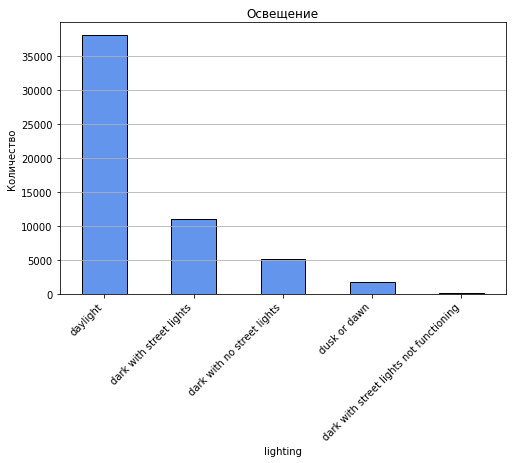

In [32]:
plot_value_counts(df, 'lighting', title = 'Освещение')

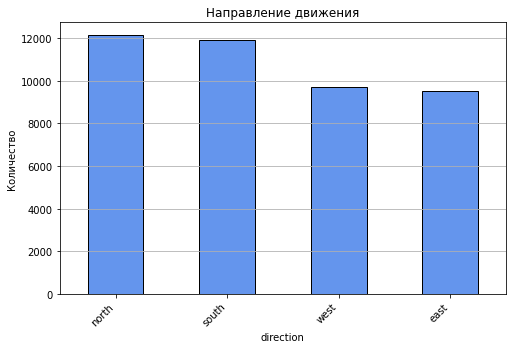

In [33]:
plot_value_counts(df, 'direction', title = 'Направление движения')

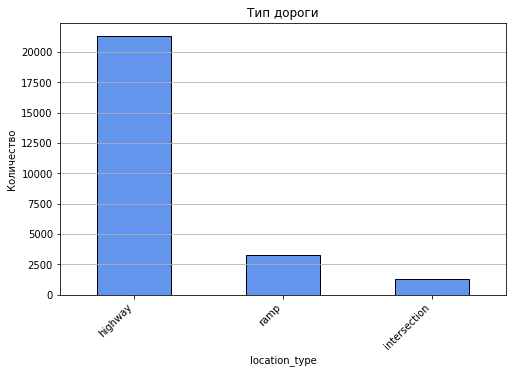

In [34]:
plot_value_counts(df, 'location_type', title = 'Тип дороги')

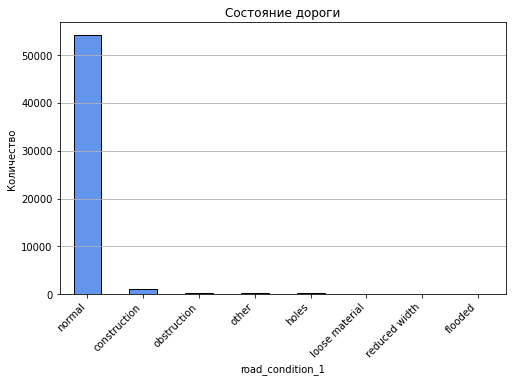

In [35]:
plot_value_counts(df, 'road_condition_1', title = 'Состояние дороги')

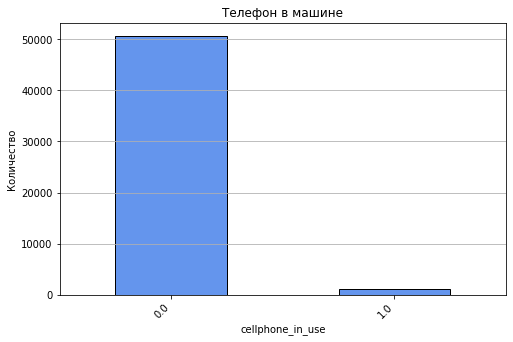

In [36]:
plot_value_counts(df, 'cellphone_in_use', title = 'Телефон в машине')

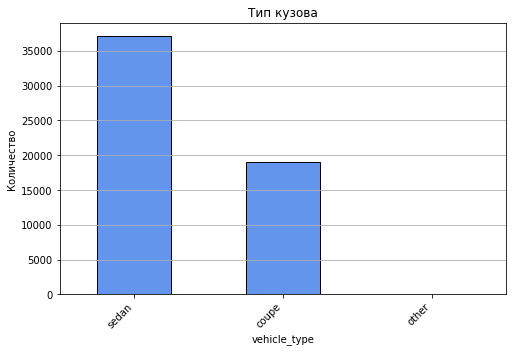

In [37]:
plot_value_counts(df, 'vehicle_type', title = 'Тип кузова')

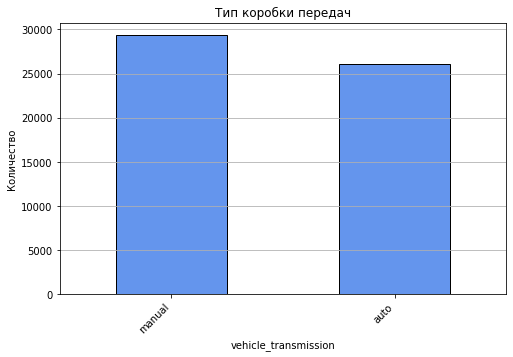

In [38]:
plot_value_counts(df, 'vehicle_transmission', title = 'Тип коробки передач')

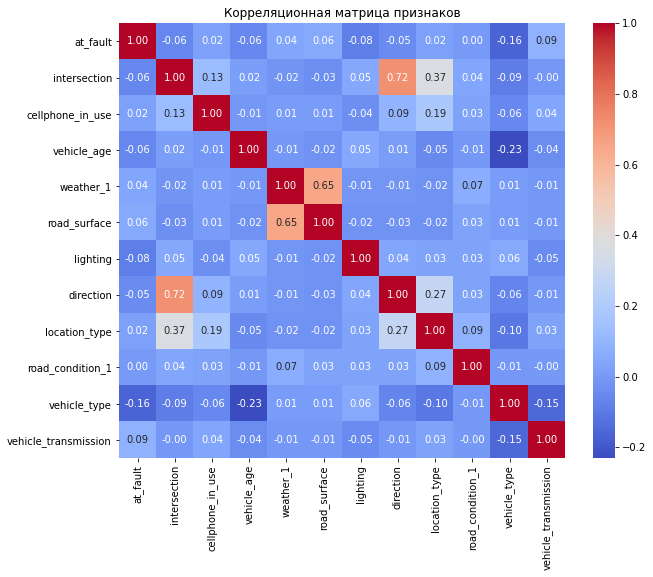

In [39]:
binary_features = ['at_fault', 'intersection', 'cellphone_in_use']
numeric_features = ['vehicle_age']
categorical_features = ['weather_1', 'road_surface', 'lighting',
                        'direction', 'location_type', 'road_condition_1',
                        'vehicle_type', 'vehicle_transmission']

df_corr = df.copy()

le = LabelEncoder()
for col in binary_features + categorical_features:
    df_corr[col] = le.fit_transform(df_corr[col])

all_features = binary_features + numeric_features + categorical_features

corr_matrix = df_corr[all_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляционная матрица признаков")
plt.show()

Сильной мультиколлениарности не видно, оставим все признаки для обучения.

In [40]:
(df.isna().mean() * 100).round(2)

at_fault                 0.00
vehicle_age              3.01
weather_1                0.30
road_surface             0.62
lighting                 0.27
intersection             0.31
direction               23.14
location_type           53.90
road_condition_1         0.44
cellphone_in_use         7.95
vehicle_type             0.00
vehicle_transmission     1.53
dtype: float64

In [41]:
df = df.dropna()
df.shape

(22948, 12)

Доля пропущенных значений не превышает 3% по каждому признаку.
С учётом большого объёма данных было принято решение удалить строки
с пропусками, чтобы избежать искажения распределений признаков.

In [42]:
df['at_fault'].value_counts(normalize=True)

0    0.501482
1    0.498518
Name: at_fault, dtype: float64

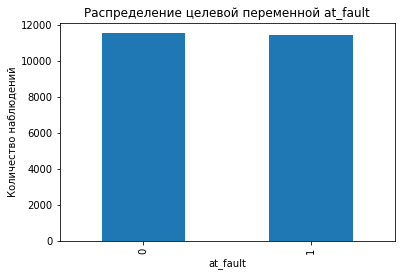

In [43]:
df['at_fault'].value_counts().plot(kind='bar')
plt.title('Распределение целевой переменной at_fault')
plt.xlabel('at_fault')
plt.ylabel('Количество наблюдений')
plt.show()

Классы целевой переменной распределены неравномерно.
Для оценки качества моделей будет использована метрика ROC-AUC,
устойчивая к дисбалансу классов.

In [44]:
df[['vehicle_age', 'intersection']].describe()

,vehicle_age,intersection
count,22948.00000,22948.000000
mean,4.96771,0.000087
std,2.97365,0.009335
min,0.00000,0.000000
25%,3.00000,0.000000
50%,4.00000,0.000000
75%,7.00000,0.000000
max,16.00000,1.000000


In [45]:
for col in ['weather_1', 'road_surface', 'lighting']:
    display(df[col].value_counts())

clear      17979
cloudy      3871
raining      894
snowing      118
fog           66
other         20
Name: weather_1, dtype: int64

dry         20244
wet          2437
snowy         257
slippery       10
Name: road_surface, dtype: int64

daylight                                   15552
dark with street lights                     3500
dark with no street lights                  3137
dusk or dawn                                 693
dark with street lights not functioning       66
Name: lighting, dtype: int64

## Построим ML

Из - за дисбаланса классов, для оценки модели будем использовать метрику roc auc. 

In [46]:
X = df.drop('at_fault', axis=1)
y = df['at_fault']

num_features = ["vehicle_age"]
bin_features = [
    "intersection",
    "cellphone_in_use"
]
cat_features = ['weather_1', 'road_surface', 'lighting',
                'direction', 'location_type', 'road_condition_1',
                'vehicle_type', 'vehicle_transmission']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

In [48]:
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        drop="first",
        handle_unknown="error",
        sparse=False
    ))
])

bin_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("bin", bin_transformer, bin_features),
        ("cat", cat_transformer, cat_features)
    ],
    remainder="drop"
)

In [ ]:
pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs"]
}

gs_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

gs_lr.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END .................model__C=0.01, model__solver=lbfgs; total time=   0.8s
[CV] END .................model__C=0.01, model__solver=lbfgs; total time=   1.0s
[CV] END .................model__C=0.01, model__solver=lbfgs; total time=   0.9s
[CV] END .................model__C=0.01, model__solver=lbfgs; total time=   0.8s
[CV] END .................model__C=0.01, model__solver=lbfgs; total time=   0.9s
[CV] END ..................model__C=0.1, model__solver=lbfgs; total time=   1.4s
[CV] END ..................model__C=0.1, model__solver=lbfgs; total time=   1.5s
[CV] END ..................model__C=0.1, model__solver=lbfgs; total time=   1.5s
[CV] END ..................model__C=0.1, model__solver=lbfgs; total time=   1.3s
[CV] END ..................model__C=0.1, model__solver=lbfgs; total time=   1.4s
[CV] END ....................model__C=1, model__solver=lbfgs; total time=   2.9s
[CV] END ....................model__C=1, model__s

In [ ]:
pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

gs_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

gs_rf.fit(X_train, y_train)

In [ ]:
pipe_gb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

param_grid_gb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5]
}

gs_gb = GridSearchCV(
    pipe_gb,
    param_grid_gb,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

gs_gb.fit(X_train, y_train)


In [ ]:
models = {
    "LogReg": gs_lr,
    "RandomForest": gs_rf,
    "GradientBoosting": gs_gb
}

for name, gs in models.items():
    print(
        name,
        "ROC-AUC:",
        gs.best_score_,
        "Params:",
        gs.best_params_
    )


In [ ]:
best_model = gs_rf.best_estimator_ 

y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

print("Test ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))


Лучшая модель это GradientBoosting ROC-AUC: 0.679117071087874 Params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}

In [ ]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Не виноват", "Виноват"])

disp.plot(cmap=plt.cm.Blues)
plt.title("Матрица ошибок")
plt.show()

In [ ]:
preprocessor = best_model.named_steps['preprocessor']
feature_names = list(num_features)

if 'bin' in preprocessor.named_transformers_:
    feature_names += list(bin_features)

cat_transformer = preprocessor.named_transformers_['cat']
onehot = cat_transformer.named_steps['onehot']

if hasattr(onehot, 'get_feature_names_out'):
    cat_features_transformed = onehot.get_feature_names_out(cat_features)
else:
    cat_features_transformed = onehot.get_feature_names(cat_features)

feature_names += list(cat_features_transformed)


importances = best_model.named_steps['model'].feature_importances_
indices = np.argsort(importances)[::-1] 

plt.figure(figsize=(12,6))
plt.title("Важность признаков")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
sns.boxplot(x=y, y=df.loc[X_test.index, 'vehicle_age'])
plt.title("Зависимость возраста автомобиля и вероятности ДТП")
plt.xlabel("at_fault")
plt.ylabel("vehicle_age (лет)")
plt.show()

## Вывод

Модель *RandomForest* показала ROC-AUC ≈ 0.7, что говорит о умеренной способности предсказывать риск ДТП.

**Основные факторы риска:** Освещение и возраст автомобиля и тип кузова.

Полнота для класса "виноват" низкая, поэтому система должна использоваться как предупреждающий инструмент, а не как абсолютное решение.

*Рекомендации по оборудованию автомобиля и сбору данных*

Возраст автомобиля:

Контроль состояния автомобиля через телеметрию: тормоза, шины, амортизаторы, система стабилизации.

Система предупреждения водителя о повышенном риске при старых или изношенных автомобилях.

Дополнительно полезные данные для улучшения модели:

Состояние водителя (трезвость, усталость, приём лекарств).

История нарушений и аварий водителя.

Телеметрические данные (скорость, ускорение, торможение).

Освещённость, погодные условия в момент поездки (можно получать из API погоды в реальном времени).

*Система предупреждений:*

Перед поездкой водитель получает оценку риска маршрута.

В случае высокого риска система предлагает альтернативный маршрут или дополнительную осторожность.
